# Find the allele counts for rs12913832

In [2]:
file_name = "../../resources/VCF_files/1000G_subset_chr15.vcf"
variant_position = '28365618'


def extract_variant_line(file_name, rs_position):
    fh = open(file_name)
    for line in fh:
        if line.startswith('#'):
            continue
        cols = line.strip().split()
        if cols[1] == rs_position:
            return line
        
def extract_genotypes(line):
    wt  = 0
    het = 0
    hom = 0

    cols = line.strip().split()
    zero = cols[3]
    one  = cols[4]
    for genotype in cols[9:]:
        if genotype == '0|0':
            wt += 1
        elif genotype == '0|1' or genotype == '1|0':
            het += 1
        elif genotype == '1|1':
            hom += 1
        else:
            print('found not matching', genotype)
    genotypes = { f"{zero}{zero}": wt
                , f"{zero}{one}": het
                , f"{one}{one}": hom }
    return genotypes


line = extract_variant_line(file_name, variant_position)
genotypes = extract_genotypes(line)
    
print(genotypes)

{'AA': 35, 'AG': 2, 'GG': 3}


# Plot the allele frequencies

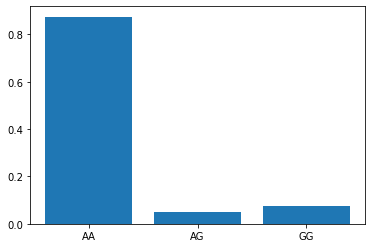

In [3]:
from matplotlib import pyplot as plt

frequencies = {key: value/sum(genotypes.values()) for key, value in genotypes.items()}

plt.bar(frequencies.keys(), frequencies.values())
plt.show()